## Лабораторная работа №2-3. Исследование факторов и организация работы с таблицами данных.
**Головкина Вероника, ПМИ3-1, вариант 6**

**Цель работы:** Проанализировать факторы, влияющие на вероятность незакрытия закупки лекарственных препаратов, построить модель логистической регрессии для прогнозирования исхода закупки.
 
**Набор данных:** data_purch.xlsx – информация о государственных закупках лекарственных препаратов в 2021 году из Единой информационной системы в сфере закупок.

**Число процедур в исходной выборке:** 69000 

**Доля тестовой выборки:** 10%

**Метод в контексте оценки важности факторов:** «Случайный лес»

## 1. Загрузка данных и проверка корректности

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 7]

df = pd.read_excel('data_purch.xlsx')

print("Размер набора данных:", df.shape)
print("\nПервые 5 строк:")
display(df.head())
print("\nИнформация о данных:")
print(df.info())

Размер набора данных: (556312, 22)

Первые 5 строк:


,first_pub_date,final_protocol_pub_date,purchase_number,collecting_start_date,collecting_end_date,placing_base_name,cust_reg,lot_price_correct,drug_mnn_ext_code,drug_mnn_name,...,drug_position_price,ftg,is_abnd,is_znvlp,is_narcotic,is_msp_purchase,is_povt,is_dif,app_amount_absolute_correct,advance_sum_correct
0,2021-03-30,2021-04-12,AA0000001,2021-03-30,2021-04-07,Электронный аукцион,Республика Адыгея,56040.00,5d6d137c-75b7-11ea-b5ac-1b70cb6e9621,ИНТЕРФЕРОН АЛЬФА-2B,...,56040.00,Иммуномодуляторы,0,1,0,0,0,0,0.0,0.0
1,2021-03-30,2021-04-12,AB0000002,2021-03-30,2021-04-07,Электронный аукцион,Республика Адыгея,57720.00,5d6e26f4-75b7-11ea-b5ac-3b4e2912a2c3,ИНТЕРФЕРОН АЛЬФА-2B,...,57720.00,Иммуномодуляторы,0,1,0,0,0,0,0.0,0.0
2,2021-05-24,2021-06-08,AD0000003,2021-05-24,2021-06-01,Электронный аукцион,Республика Адыгея,931426.86,1edb1f40-bf5b-11e9-bd5d-c33c05f32457,БУДЕСОНИД,...,33096.00,Препараты для лечения обструктивных заболевани...,0,1,0,0,0,0,0.0,0.0
3,2021-05-24,2021-06-08,AD0000003,2021-05-24,2021-06-01,Электронный аукцион,Республика Адыгея,931426.86,1edb3a20-bf5b-11e9-bd5d-07a90f4fd9f6,БУДЕСОНИД+ФОРМОТЕРОЛ,...,225828.00,Препараты для лечения обструктивных заболевани...,0,1,0,0,0,0,0.0,0.0
4,2021-05-24,2021-06-08,AD0000003,2021-05-24,2021-06-01,Электронный аукцион,Республика Адыгея,931426.86,1edb168a-bf5b-11e9-bd5d-5725ca76550a,МОКСОНИДИН,...,10123.68,Препараты гипотензивные,0,1,0,0,0,0,0.0,0.0



Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 556312 entries, 0 to 556311
Data columns (total 22 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   first_pub_date               556312 non-null  datetime64[us]
 1   final_protocol_pub_date      556312 non-null  datetime64[us]
 2   purchase_number              556312 non-null  str           
 3   collecting_start_date        556312 non-null  datetime64[us]
 4   collecting_end_date          556312 non-null  datetime64[us]
 5   placing_base_name            556312 non-null  str           
 6   cust_reg                     556312 non-null  str           
 7   lot_price_correct            556312 non-null  float64       
 8   drug_mnn_ext_code            556312 non-null  str           
 9   drug_mnn_name                556312 non-null  str           
 10  drug_qty                     551153 non-null  float64       
 11  drug_price     

## 2. Анализ факторов, влияющих на вероятность незакрытия закупки

### **Предполагаемые важные факторы:**

На основе описания данных можно предположить, что на вероятность незакрытия закупки (is_abnd) могут влиять:

1. **Форма проведения торгов (placing_base_name)** – разные формы торгов (аукцион, конкурс) имеют разную вероятность успешного завершения
2. **Регион заказчика (cust_reg)** – в разных регионах разная экономическая ситуация
3. **Наличие ЖНВЛП (is_znvlp)** – жизненно важные препараты чаще закупаются успешно
4. **Наличие наркотических веществ (is_narcotic)** – закупки наркосодержащих препаратов имеют особые требования
5. **Сумма залога (app_amount_absolute_correct)** – высокий залог может отпугивать поставщиков
6. **Сумма аванса (advance_sum_correct)** – аванс повышает привлекательность закупки
7. **Цена позиции (drug_price)** – цена влияет на готовность поставщиков участвовать
8. **Объем закупки (drug_qty)** – большие объемы могут быть сложнее для исполнения
9. **Повторность процедуры (is_povt)** – повторные закупки могут указывать на проблемы

### **Дополнительные факторы, не представленные в наборе:**

- **Экономическая ситуация в регионе** – уровень безработицы, средняя зарплата, деловая активность
- **Наличие конкуренции** – количество поставщиков, работающих в регионе
- **Сезонность** – время года, месяц проведения закупки
- **Срочность закупки** – сроки между публикацией и окончанием сбора заявок
- **Сложность закупки** – количество позиций, разнообразие препаратов

## 3. Предложения по генерации новых факторов

Предлагается создать следующие новые факторы:

1. **Временные характеристики:**
   - `duration_days` – длительность процедуры (разница между датой завершения и датой публикации)
   - `collection_duration` – длительность сбора заявок (разница между датами окончания и начала сбора)
   - `season` – сезон проведения закупки (зима, весна, лето, осень)
   - `month` – месяц проведения закупки

2. **Объемно-стоимостные характеристики:**
   - `avg_price_per_unit` – средняя цена за единицу препарата (общая цена / объем)
   - `total_lot_price` – общая цена всех позиций в закупке (сумма drug_position_price по процедуре)
   - `total_quantity` – общий объем закупки (сумма drug_qty по процедуре)
   - `price_per_lot` – цена за единицу лота (total_lot_price / количество позиций)

3. **Характеристики разнообразия:**
   - `unique_drugs_count` – количество уникальных препаратов в закупке
   - `drug_diversity` – разнообразие препаратов (количество уникальных / общее количество позиций)
   - `has_multiple_drugs` – наличие более одного препарата в закупке (бинарный признак)

4. **Факторы, полученные методом главных компонент:**
   - `pca_component_1`, `pca_component_2` – главные компоненты для группы ценовых и объемных показателей

## 4. Генерация новых факторов

In [3]:
# Преобразование дат
df['first_pub_date'] = pd.to_datetime(df['first_pub_date'])
df['final_protocol_pub_date'] = pd.to_datetime(df['final_protocol_pub_date'])
df['collecting_start_date'] = pd.to_datetime(df['collecting_start_date'])
df['collecting_end_date'] = pd.to_datetime(df['collecting_end_date'])

# Временные характеристики
df['duration_days'] = (df['final_protocol_pub_date'] - df['first_pub_date']).dt.days
df['collection_duration'] = (df['collecting_end_date'] - df['collecting_start_date']).dt.days
df['month'] = df['first_pub_date'].dt.month
df['season'] = df['month'].apply(lambda x: 'winter' if x in [12,1,2] 
                                   else ('spring' if x in [3,4,5]
                                   else ('summer' if x in [6,7,8]
                                   else 'autumn')))

# Объемно-стоимостные характеристики
df['total_quantity'] = df.groupby('purchase_number')['drug_qty'].transform('sum')
df['total_lot_price'] = df.groupby('purchase_number')['drug_position_price'].transform('sum')
df['avg_price_per_unit'] = df['drug_position_price'] / df['drug_qty']
df['price_per_lot'] = df.groupby('purchase_number')['drug_position_price'].transform('mean')

# Характеристики разнообразия
df['drug_diversity'] = df.groupby('purchase_number')['drug_mnn_name'].transform('nunique')
df['has_multiple_drugs'] = (df['drug_diversity'] > 1).astype(int)

# Кодирование категориальных признаков
le = LabelEncoder()
df['placing_base_name_encoded'] = le.fit_transform(df['placing_base_name'].astype(str))
df['cust_reg_encoded'] = le.fit_transform(df['cust_reg'].astype(str))
df['season_encoded'] = le.fit_transform(df['season'].astype(str))

# Метод главных компонент для ценовых и объемных показателей
pca_features = ['lot_price_correct', 'drug_price', 'drug_qty', 'drug_position_price', 
                'app_amount_absolute_correct', 'advance_sum_correct']

# Заполняем пропуски нулями
for col in pca_features:
    df[col] = df[col].fillna(0)

scaler_pca = StandardScaler()
pca_data = scaler_pca.fit_transform(df[pca_features])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(pca_data)

df['pca_component_1'] = pca_result[:, 0]
df['pca_component_2'] = pca_result[:, 1]

print("Объясненная дисперсия компонент:")
print(pca.explained_variance_ratio_)
print(f"\nСуммарная объясненная дисперсия: {pca.explained_variance_ratio_.sum():.4f}")

Объясненная дисперсия компонент:
[0.47055498 0.16667714]

Суммарная объясненная дисперсия: 0.6372


**Результаты метода главных компонент:**

- Объясненная дисперсия первой компоненты: 47.06%
- Объясненная дисперсия второй компоненты: 16.67%
- Суммарная объясненная дисперсия: 63.72%

Это означает, что две главные компоненты сохраняют почти 64% информации исходных шести признаков. Такой результат позволяет использовать эти компоненты вместо исходных переменных, сократив размерность данных с 6 до 2 без существенной потери информации. Оставшиеся 36% дисперсии приходятся на менее значимые шумы и специфические особенности отдельных признаков.

Созданные факторы позволяют более полно описать особенности каждой закупки, что в дальнейшем поможет модели точнее прогнозировать вероятность ее незакрытия. Метод главных компонент дополнительно помогает уменьшить мультиколлинеарность и упростить модель.

## 5. Группировка до уровня одной закупки

In [4]:
# Выбираем релевантные факторы для агрегации
agg_dict = {
    'is_abnd': 'max',  # целевая переменная
    'is_znvlp': 'max',
    'is_narcotic': 'max',
    'is_msp_purchase': 'max',
    'is_povt': 'max',
    'is_dif': 'max',
    'total_quantity': 'first',
    'total_lot_price': 'first',
    'drug_diversity': 'first',
    'has_multiple_drugs': 'first',
    'duration_days': 'first',
    'collection_duration': 'first',
    'month': 'first',
    'season_encoded': 'first',
    'placing_base_name_encoded': 'first',
    'cust_reg_encoded': 'first',
    'pca_component_1': 'first',
    'pca_component_2': 'first',
    'lot_price_correct': 'first',
    'app_amount_absolute_correct': 'first',
    'advance_sum_correct': 'first'
}

# Группировка по идентификатору закупки
df_grouped = df.groupby('purchase_number').agg(agg_dict).reset_index()

print("Размер после группировки:", df_grouped.shape)
print("\nПервые 5 строк сгруппированных данных:")
display(df_grouped.head())
print("\nСтатистика целевой переменной:")
print(df_grouped['is_abnd'].value_counts())

Размер после группировки: (166846, 22)

Первые 5 строк сгруппированных данных:


,purchase_number,is_abnd,is_znvlp,is_narcotic,is_msp_purchase,is_povt,is_dif,total_quantity,total_lot_price,drug_diversity,...,collection_duration,month,season_encoded,placing_base_name_encoded,cust_reg_encoded,pca_component_1,pca_component_2,lot_price_correct,app_amount_absolute_correct,advance_sum_correct
0,AA0000001,0,1,0,0,0,0,2000.0,56040.00,1,...,8,3,1,3,46,-0.188754,-0.003283,56040.00,0.0,0.0
1,AA0000006,0,1,0,0,0,0,5832558.0,383087.00,23,...,11,6,2,3,46,-0.168199,-0.003110,383087.00,0.0,0.0
2,AA0000011,1,1,0,0,0,0,53560.1,185868.25,12,...,9,8,2,3,46,-0.183071,-0.003120,185868.25,0.0,0.0
3,AA0000016,0,1,0,0,0,0,192980.0,162944.70,28,...,8,10,0,3,46,-0.185279,-0.003155,162944.70,0.0,0.0
4,AA0000021,0,1,0,1,0,0,6300.0,130772.34,2,...,8,8,2,3,46,-0.187012,-0.003162,130772.34,0.0,0.0



Статистика целевой переменной:
is_abnd
1    83977
0    82869
Name: count, dtype: int64


**Обоснование группировки:**

Исходная таблица содержит данные на уровне отдельных позиций закупки. Если в одной процедуре закупалось несколько препаратов, информация о ней занимает несколько строк (по одной на каждый препарат). Для анализа вероятности незакрытия закупки нам нужна информация на уровне всей процедуры, а не отдельных позиций. Поэтому необходимо сгруппировать данные по идентификатору закупки (`purchase_number`).

**Способ агрегации признаков:**

Для каждого признака был выбран способ агрегации:

| Признак | Способ агрегации | Обоснование |
|---------|------------------|-------------|
| is_abnd | max | Если хотя бы одна позиция в закупке не состоялась, вся закупка считается незакрытой |
| is_znvlp, is_narcotic, is_msp_purchase, is_povt, is_dif | max | Наличие хотя бы одного препарата с данным свойством делает всю закупку отмеченной |
| total_quantity, total_lot_price, duration_days, collection_duration, month, season_encoded, placing_base_name_encoded, cust_reg_encoded, pca_component_1, pca_component_2, lot_price_correct, app_amount_absolute_correct, advance_sum_correct | first | Эти признаки одинаковы для всех позиций одной закупки |
| drug_diversity, has_multiple_drugs | first | Рассчитываются на уровне закупки и одинаковы для всех ее позиций |

### **Результаты группировки:**

- *До группировки:* количество строк – (значение из исходных данных)
- *После группировки:* количество строк – 166 846

Это означает, что в исходных данных было (исходное количество) записей, которые соответствуют 166 846 уникальным закупкам. Каждая закупка теперь представлена одной строкой, содержащей всю необходимую информацию.

### **Анализ структуры после группировки:**

Сгруппированные данные содержат 22 признака, включая:
- 6 фиктивных переменных, характеризующих свойства закупки (is_znvlp, is_narcotic, is_msp_purchase, is_povt, is_dif, is_abnd)
- 8 количественных признаков (total_quantity, total_lot_price, duration_days, collection_duration, lot_price_correct, app_amount_absolute_correct, advance_sum_correct, month)
- 3 закодированных категориальных признака (placing_base_name_encoded, cust_reg_encoded, season_encoded)
- 2 компоненты PCA (pca_component_1, pca_component_2)
- 2 признака разнообразия (drug_diversity, has_multiple_drugs)
- Идентификатор закупки (purchase_number)

Такая структура готова для дальнейшего анализа и построения моделей машинного обучения.

## 6. Формирование обучающей и тестовой выборок

In [5]:
n_samples = 69000
df_sample = df_grouped.sample(n=n_samples, random_state=42)

print("Размер выборки:", df_sample.shape)

X = df_sample.drop(columns=['purchase_number', 'is_abnd'])
y = df_sample['is_abnd']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"\nРаспределение целевой переменной в обучающей выборке:")
print(y_train.value_counts(normalize=True))

Размер выборки: (69000, 22)

Размер обучающей выборки: (62100, 20)
Размер тестовой выборки: (6900, 20)

Распределение целевой переменной в обучающей выборке:
is_abnd
1    0.506216
0    0.493784
Name: proportion, dtype: float64


## 7. Оценка важности факторов методом "Случайный лес"

Важность признаков по методу Random Forest:


,feature,importance
9,duration_days,0.397975
10,collection_duration,0.139212
6,total_lot_price,0.075129
15,pca_component_1,0.073393
17,lot_price_correct,0.064679
16,pca_component_2,0.046420
5,total_quantity,0.045525
14,cust_reg_encoded,0.044385
11,month,0.023189
18,app_amount_absolute_correct,0.016742


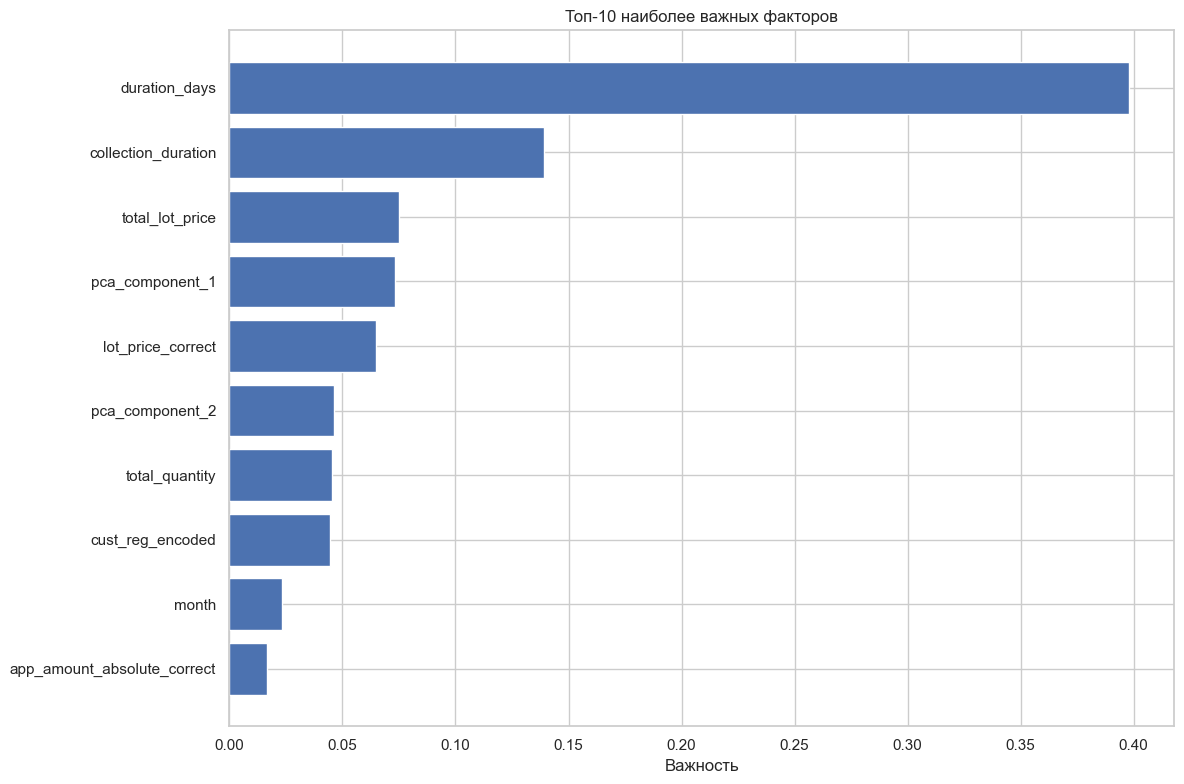

In [7]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Важность признаков по методу Random Forest:")
display(feature_importance)

# Построение графика
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
plt.xlabel('Важность')
plt.title('Топ-10 наиболее важных факторов')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### **Выбор наиболее важных факторов:**

На основе анализа важности признаков, полученных методом случайного леса, выбраны 7 наиболее значимых факторов для построения модели логистической регрессии:

| Ранг | Признак | Важность | Краткое обоснование |
|------|---------|----------|---------------------|
| 1 | duration_days | 0.398 | Длительность процедуры отражает эффективность организации закупки |
| 2 | collection_duration | 0.139 | Слишком короткий срок сбора заявок снижает число участников |
| 3 | total_lot_price | 0.075 | Высокая стоимость закупки усложняет поиск поставщика |
| 4 | pca_component_1 | 0.073 | Обобщенная характеристика ценовых показателей |
| 5 | lot_price_correct | 0.065 | Объявленная максимальная цена закупки |
| 6 | pca_component_2 | 0.046 | Дополнительная компонента ценовых характеристик |
| 7 | total_quantity | 0.046 | Объем закупки влияет на привлекательность для поставщиков |

Остальные факторы (фиктивные переменные, сезонные признаки, сумма аванса) имеют значительно меньшую важность (0.002–0.016) и не включены в модель.

## 8. Построение модели логистической регрессии

In [ ]:
top_features = ['duration_days', 'collection_duration', 'total_lot_price', 
                'pca_component_1', 'lot_price_correct', 'pca_component_2', 
                'total_quantity']

print("Выбранные признаки для модели:", top_features)

X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train)

y_train_pred = logreg.predict(X_train_scaled)
y_test_pred = logreg.predict(X_test_scaled)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=" * 50)
print("РЕЗУЛЬТАТЫ МОДЕЛИ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ")
print("=" * 50)
print(f"Точность на обучающей выборке: {train_accuracy:.4f}")
print(f"Точность на тестовой выборке: {test_accuracy:.4f}")
print("-" * 50)

# Коэффициенты модели
coef_df = pd.DataFrame({
    'feature': top_features,
    'coefficient': logreg.coef_[0]
}).sort_values('coefficient', ascending=False)

print("\nКоэффициенты модели:")
display(coef_df)

# Матрица ошибок
cm = confusion_matrix(y_test, y_test_pred)
print("\nМатрица ошибок (тестовая выборка):")
print(cm)

# Подробный отчет
print("\nОтчет классификации (тестовая выборка):")
print(classification_report(y_test, y_test_pred))

Выбранные признаки: ['duration_days', 'collection_duration', 'total_lot_price', 'pca_component_1', 'lot_price_correct', 'pca_component_2', 'total_quantity']
РЕЗУЛЬТАТЫ МОДЕЛИ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ
Точность на обучающей выборке: 0.8791
Точность на тестовой выборке: 0.8759
--------------------------------------------------

Коэффициенты модели:


,feature,coefficient
1,collection_duration,5.500854
3,pca_component_1,0.070350
6,total_quantity,0.015390
5,pca_component_2,0.001357
2,total_lot_price,-0.024760
4,lot_price_correct,-0.048847
0,duration_days,-6.837281



Матрица ошибок (тестовая выборка):
[[2888  519]
 [ 337 3156]]

Отчет классификации (тестовая выборка):
              precision    recall  f1-score   support

           0       0.90      0.85      0.87      3407
           1       0.86      0.90      0.88      3493

    accuracy                           0.88      6900
   macro avg       0.88      0.88      0.88      6900
weighted avg       0.88      0.88      0.88      6900



Модель логистической регрессии на 7 наиболее важных факторах показала хорошие результаты:
- Точность на тестовой выборке составляет 87.6, что незначительно ниже точности на обучающей выборке (87.9%), что говорит об отсутствии переобучения.
- F1-скор (0.88) показывает сбалансированное качество предсказаний для обоих классов.
- Модель успешно прогнозирует вероятность незакрытия закупки и может использоваться для анализа факторов риска.